In [1]:
from OscTools.Dynamics import Dynamics
from OscTools.BaselineAlgorithms import *
from OscTools.Timeseries import Timeseries
import json

### Single Run

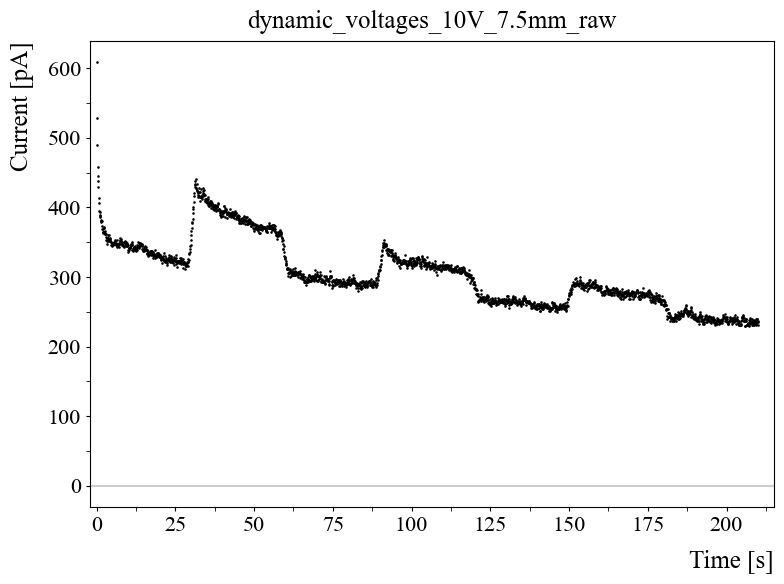

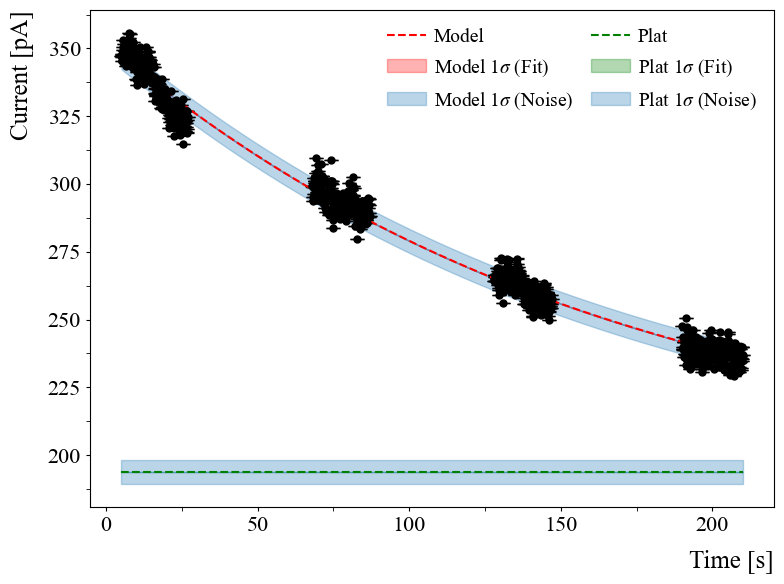

Best fit parameters : [1.57566763e-10 1.61170393e+02 1.93567639e-10 1.02950890e+00]
Best fit parameters error : [2.45497771e-15 1.08628871e-07 1.10204292e-15 3.17294186e-05]
Chi2 = 168415057.1684512 (dof = 855)


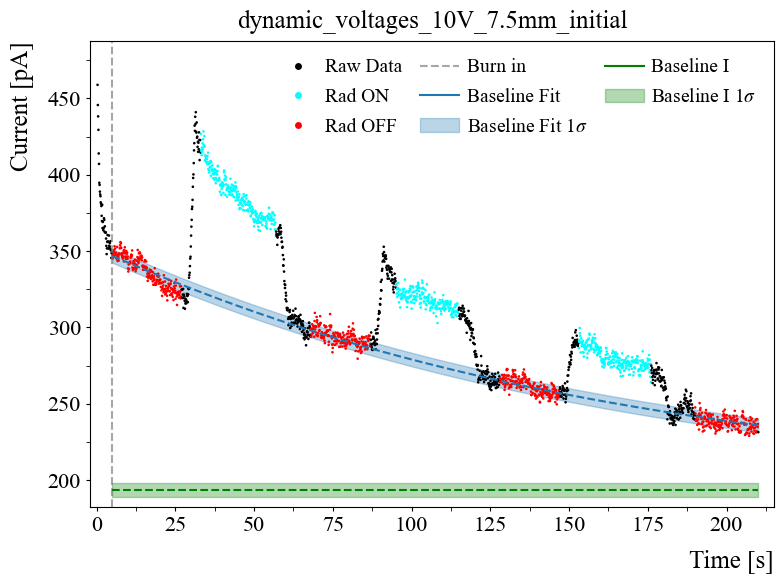

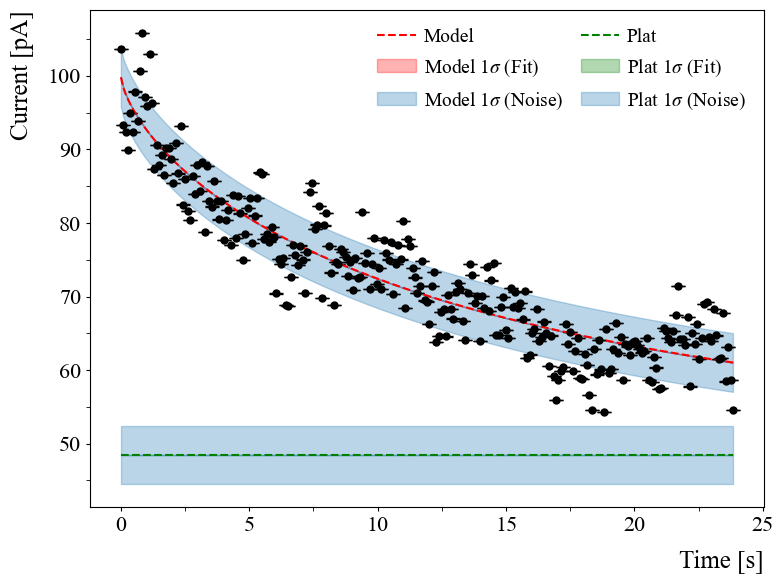

Best fit parameters : [5.13825877e-11 1.47023095e+01 4.84382041e-11 7.05108112e-01]
Best fit parameters error : [7.92107239e-15 2.96959898e-06 3.10903946e-15 1.59180598e-04]
Chi2 = 40690433.56339164 (dof = 253)


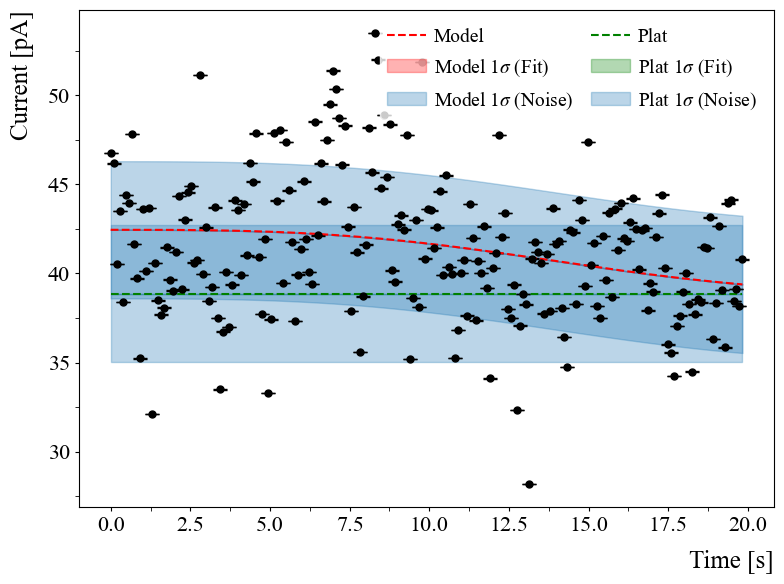

Best fit parameters : [3.59118522e-12 1.59729313e+01 3.88562333e-11 2.99999983e+00]
Best fit parameters error : [2.58414581e-15 1.11087192e-03 1.80993499e-15 4.69752080e-03]
Chi2 = 31604250.887459766 (dof = 210)


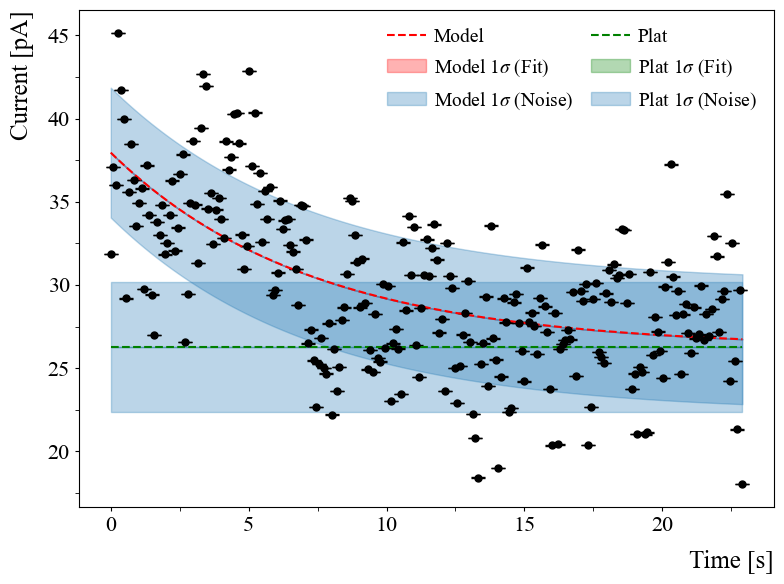

Best fit parameters : [1.17029185e-11 7.22871060e+00 2.62464600e-11]
Best fit parameters error : [2.46409984e-15 4.55570069e-03 2.18368053e-15]
Chi2 = 37487024.13798228 (dof = 244)


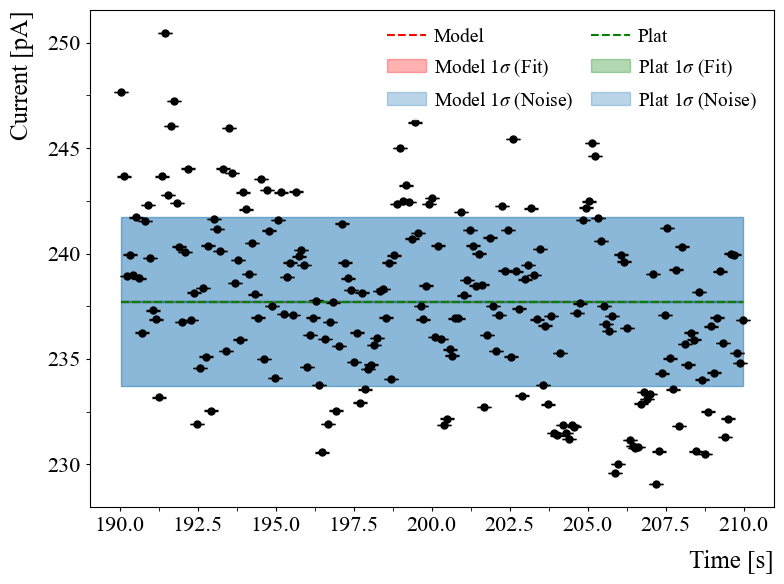

Best fit parameters : 2.3772625023255817e-10
Best fit parameters error : 6.819943394704735e-16
Chi2 = 34862079.7771749 (dof = 214)


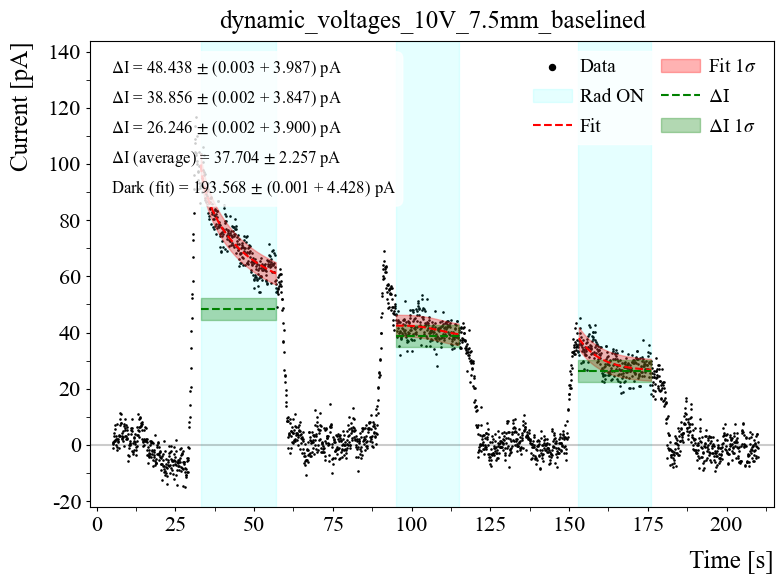

,Dark Fit,Dark Accept,Sig Fit,Sig Accept,Delta I [A],Delta I Err [A],Delta I Noise [A],Dark Noise [A],Sig Noise [A],SNR Dark,...,SDR Plat,SDR Plat Err,Dark End [A],Dark End Err [A],SDR End,SDR End Err,RC Dark [s],RC Dark Err [s],RC Sig [s],RC Sig Err [s]
0,StretchedExponential,plat,StretchedExponential,True,4.843820e-11,3.109039e-15,3.986581e-12,4.427849e-12,4.427849e-12,10.939444,...,0.250239,0.021376,2.377263e-10,6.819943e-16,0.203756,0.017194,161.170393,1.086289e-07,14.702309,0.000003
1,StretchedExponential,plat,StretchedExponential,True,3.885623e-11,1.809935e-15,3.847451e-12,4.427849e-12,4.427849e-12,8.775420,...,0.200737,0.020400,2.377263e-10,6.819943e-16,0.163449,0.016468,161.170393,1.086289e-07,15.972931,0.001111
2,StretchedExponential,plat,Exponential,True,2.624646e-11,2.183681e-15,3.899983e-12,4.427849e-12,4.427849e-12,5.927587,...,0.135593,0.020385,2.377263e-10,6.819943e-16,0.110406,0.016534,161.170393,1.086289e-07,7.228711,0.004556
-1,StretchedExponential,plat,Mixed,True,3.770376e-11,2.257488e-12,3.911338e-12,4.427849e-12,4.427849e-12,8.515143,...,0.193817,0.011954,2.377263e-10,4.427849e-12,0.158072,0.009655,161.170393,1.086289e-07,14.702315,0.000003


In [9]:
DG_PCB001_10V_7500um = Timeseries(input_path='Raw Data/DG-PCB001/dynamic_voltages_10V_7.5mm.csv',
                                  output_path='Results/DG-PCB001',
                                  timestamps_OFF=[[5, 27], [68., 87.], [128., 147.], [190., 210.]],
                                  timestamps_ON=[[33, 57.], [95., 115.], [153., 176.]],
                                  baseline_burnin=5, dataset_errors=10e-15, average_samples=True,
                                  baseline_method=StretchedExponential(),
                                  analysis_methods=[StretchedExponential(), StretchedExponential(), Exponential()],)
DG_PCB001_10V_7500um.main(get_data=True, show_plots=True, save_plots=False, save_data=False, show_fits=True)

### Full Dataset

In [2]:
config = {
    "output_directory": 'Raw Data/DG-PCB001',  # Add data output directory here
    "device_name": "DG-PCB001",
    "run_iv": True,
    "run_pv": False,
    "run_td_voltage": True,
    "run_td_standoff": True,
    "iv_range": [-30, 30, 0.5],
    "iv_standoffs": [7.5],
    "iv_type": "both",
    "pv_iv_range": [-1, 3, 0.02],
    "pv_iv_standoffs": [],
    "td_repeats": 3,
    "td_time_delay": 30,
    "td_voltage_standoffs": [7.5],
    "td_voltage_voltages": [-70, -30, -10, -5, -1, 0, 1, 5, 10, 30, 70],
    "td_standoff_voltages": [30],
    "td_standoff_standoffs": [1.5, 3.5, 5.5, 7.5, 9.5, 11.5, 13.5],
    "measurement_error" : 10e-15                                        # Change this at some point !!
}
with open('Raw Data/DG-PCB001/config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=4)

In [3]:
manual_override = {"timestamps_OFF" : [[5, 27], [68., 87.], [128., 147.], [190., 210.]],
                   "timestamps_ON" : [[33, 57.], [95., 115.], [153., 176.]],
                   "baseline_burnin" : 6.5,
                   "baseline_method" : StretchedExponential(),
                   "analysis_method" : Constant(),
                   "dark_type_accept" : 'plat',
                   "dynamic_voltages_1V_7.5mm.csv" : "omit",
                   "dynamic_voltages_-1V_7.5mm.csv" : "omit"}

Plot saved to : Results/DG-PCB001/dynamic_voltages_-70V_7.5mm_raw.pdf
Plot saved to : Results/DG-PCB001/dynamic_voltages_-70V_7.5mm_initial.pdf
Plot saved to : Results/DG-PCB001/dynamic_voltages_-70V_7.5mm_baselined.pdf
Plot saved to : Results/DG-PCB001/dynamic_voltages_-30V_7.5mm_raw.pdf
Plot saved to : Results/DG-PCB001/dynamic_voltages_-30V_7.5mm_initial.pdf
Plot saved to : Results/DG-PCB001/dynamic_voltages_-30V_7.5mm_baselined.pdf
Plot saved to : Results/DG-PCB001/dynamic_voltages_-10V_7.5mm_raw.pdf
Plot saved to : Results/DG-PCB001/dynamic_voltages_-10V_7.5mm_initial.pdf
Plot saved to : Results/DG-PCB001/dynamic_voltages_-10V_7.5mm_baselined.pdf
Plot saved to : Results/DG-PCB001/dynamic_voltages_-5V_7.5mm_raw.pdf
Plot saved to : Results/DG-PCB001/dynamic_voltages_-5V_7.5mm_initial.pdf
Plot saved to : Results/DG-PCB001/dynamic_voltages_-5V_7.5mm_baselined.pdf
Plot saved to : Results/DG-PCB001/dynamic_voltages_-1V_7.5mm_raw.pdf
File omitted: Raw Data/DG-PCB001/dynamic_voltages_-1V_

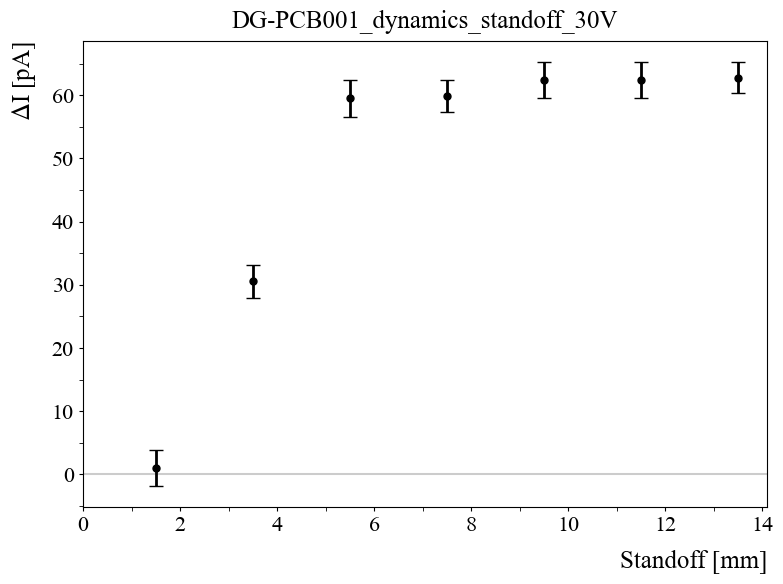

Plot saved to : Results/DG-PCB001/DG-PCB001_dynamics_voltage_7.5mm.pdf


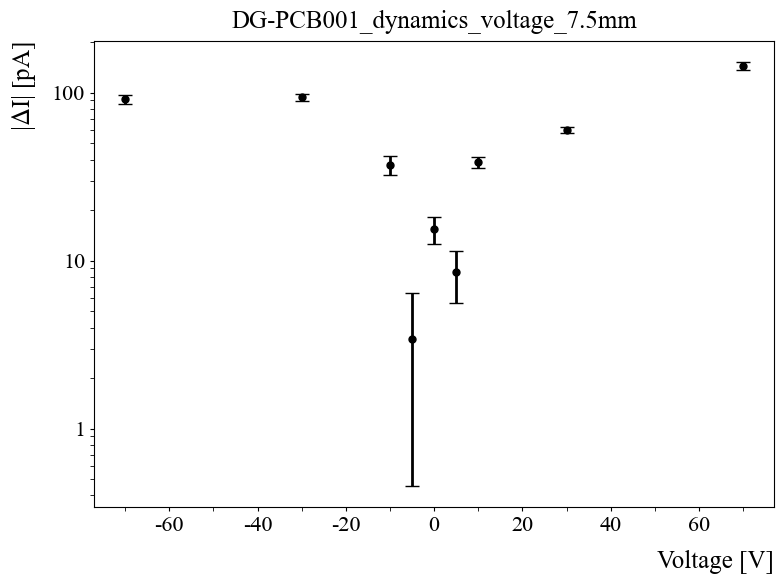

Plot saved to : Results/DG-PCB001/DG-PCB001_dynamics_dark_avg_cycled_logy.pdf


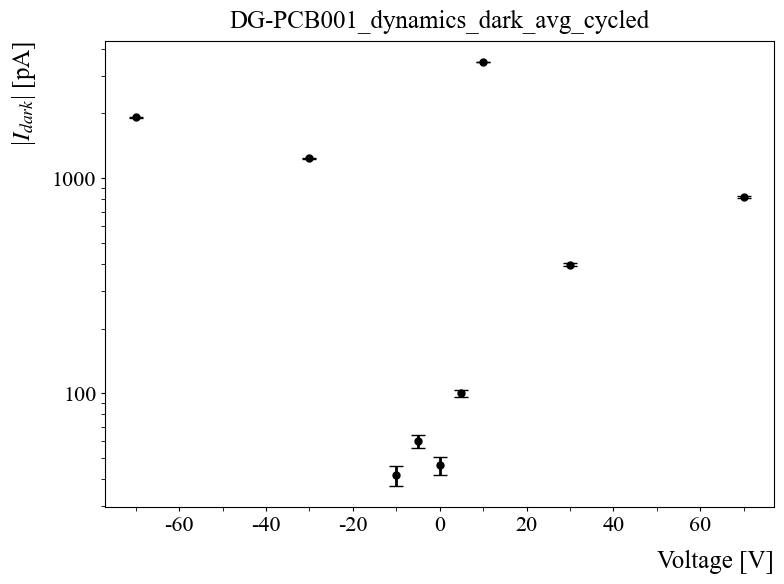

Plot saved to : Results/DG-PCB001/DG-PCB001_dynamics_dark_avg_cycled_logy_logx.pdf


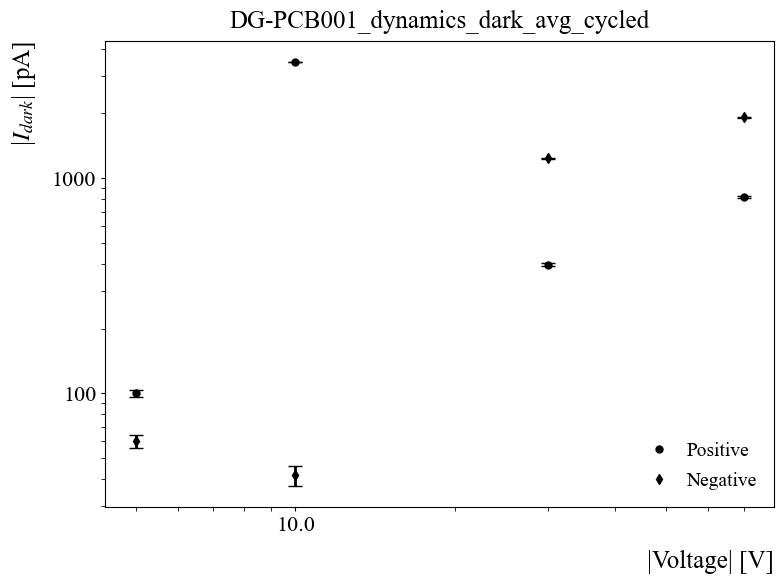

Plot saved to : Results/DG-PCB001/DG-PCB001_IV_7.5mm_away_raw.pdf
Plot saved to : Results/DG-PCB001/DG-PCB001_IV_7.5mm_away.pdf
Plot saved to : Results/DG-PCB001/DG-PCB001_IV_7.5mm_rad_raw.pdf
Plot saved to : Results/DG-PCB001/DG-PCB001_IV_7.5mm_rad.pdf
Plot saved to : Results/DG-PCB001/DG-PCB001_IV_7.5mm_both.pdf


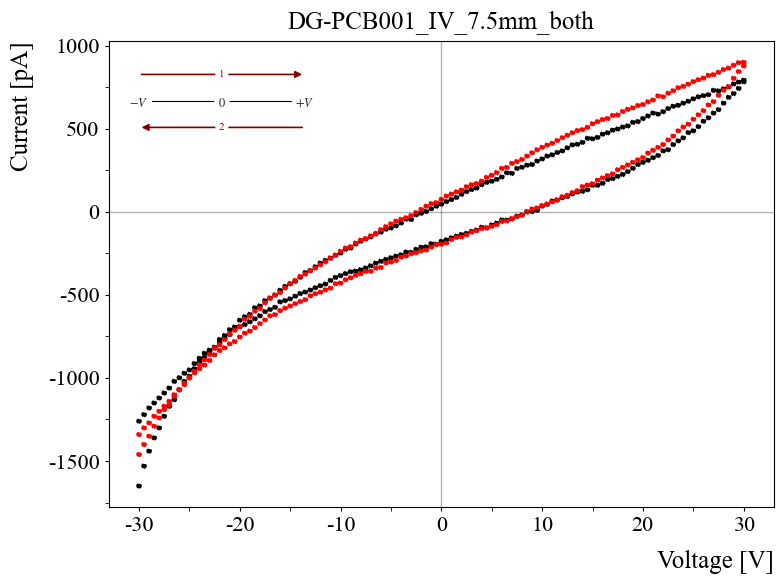

Data saved to : Results/DG-PCB001/DG-PCB001_IV_both.csv


In [11]:
DG_PCB001 = Dynamics(input_path="Raw Data/DG-PCB001", output_path="Results/DG-PCB001")
DG_PCB001.main(show_final_plots=True, save_final_plots=True, show_indiv_plots=False, save_indiv_plots=True, save_data=True,
               manual_override=manual_override, cross_parse=False, log_iv=False)

# DG_PCB001.parse_data(show_plots=False, save_plots=False, save_data=False, manual_override=manual_override, cross_parse=False)
# DG_PCB001.plot_standoff(show_plot=True, save_plot=False, show_zero=False)
# DG_PCB001.plot_voltage(show_plot=True, save_plot=False, log=True)
# DG_PCB001.plot_dark(show_plot=True, save_plot=False, logx=False, logy=True, show_fit=False)
# DG_PCB001.iv(show_final_plots=True, save_final_plots=False, save_data=False, log=False)